# Problem: v vs. p
$v := i [H, r]$

for $ \hat{V} = V(\hat{r})$ one expects $p = v$

A function to verify this for the offsite and onsite elements is implemented:

$\Delta = p - i [H,r]$

$\Delta = p - i (H S^{-1} r - r S^{-1} H)$

The test for the offsite elements calculates the operators in the basis of all atom functions within an isolated unit cell


3
(np.int64(0), np.int64(3), np.int64(5))


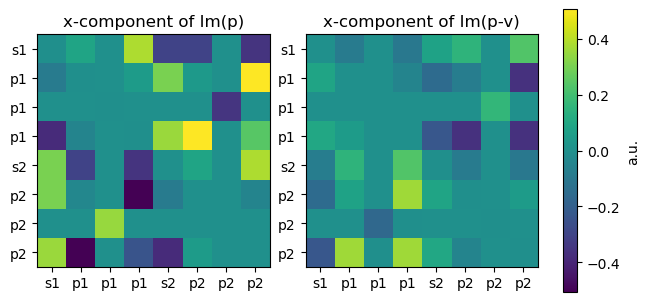

/home/juliuswillrich/Dokumente/phd/hotcent_fork_dipole/hotcent/pos_op/mat_elem_evaluation.py:814: RuntimeWarning: invalid value encountered in divide
  print(f"{el}: maximal abs deviation = {np.max(np.abs(diff))}, maximal rel deviation = {np.max(np.where(np.abs(p)>0, np.abs(diff)/np.abs(p), 0))}", file=f)


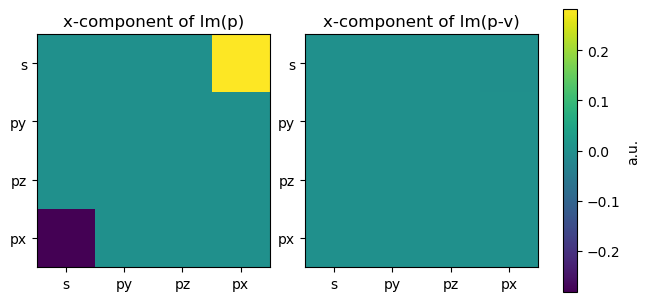

In [1]:
from hotcent.pos_op.mat_elem_evaluation import SlaterKosterIntegrator
from ase.build import graphene

maxl = {"C": 1}
atoms = graphene("CC", size=(1,1,1), vacuum=10)
integrals = SlaterKosterIntegrator(atoms_unit_cell=atoms, skpath="skfiles_consistent/sk_unique", skpath_posop="skfiles_consistent/sk_posop_unique", maxl_dict=maxl, format="unique", path_p_onsite="skfiles_consistent/onsite_momentum")
integrals.check_p_v_offsite()
integrals.check_p_v_onsite()


In [2]:
!cat offsite_p-v-consistency.txt

onsite blocks: max|p - v| = 6.121e-02 a.u., relative to max|p|: 2.172e-01
offsite blocks: max|p - v| = 2.784e-01 a.u., relative to max|p|: 9.881e-01
entries with p = 0 but v != 0: 24

# component x: p - v
 (0.000000000000000000e+00+2.421703393373775270e-10j)  (0.000000000000000000e+00-6.082503668983117728e-02j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00-4.542597762297356789e-02j)  (0.000000000000000000e+00+1.853499522031598623e-02j)  (0.000000000000000000e+00+7.518417060409188224e-02j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+1.261400705094572472e-01j)
 (0.000000000000000000e+00+6.082503638440719257e-02j)  (0.000000000000000000e+00+1.106026797925707683e-10j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00-3.533789081619939654e-02j)  (0.000000000000000000e+00-7.518417071135038987e-02j)  (0.000000000000000000e+00-6.929331129647162135e-02j)  (0.000000000000000000e+00+0.0000000000

The accordance of $p$ and $v$ is rather bad. This might have the following causes:
- numerical imprecision at any point in the calculation
- basis set truncation error
- onsite H not consistent with p and r
- actual bugs

Which one of theses is the cause?

Rule out basis set incompleteness: For onsite elements of $H, r, p$ no resolution of identity required since eigenbasis of $H$

/home/juliuswillrich/Dokumente/phd/hotcent_fork_dipole/hotcent/pos_op/mat_elem_evaluation.py:812: RuntimeWarning: invalid value encountered in divide
  print(f"{el}: maximal abs deviation = {np.max(np.abs(diff))}, maximal rel deviation = {np.max(np.where(np.abs(p)>0, np.abs(diff)/np.abs(p), 0))}", file=f)


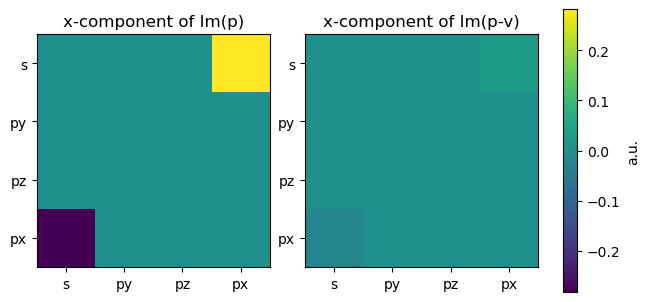

In [3]:
integrals.check_p_v_onsite()

In [4]:

!cat onsite_p-v-consistency.txt

C: maximal abs deviation = 0.024286071155001338, maximal rel deviation = 0.08618670633866728
 (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+2.428607115500133751e-02j)
 (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)
 (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)
 (0.000000000000000000e+00-2.428607115500130975e-02j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)

 (0.000000000000000000e+00+0.0000000000000

To estimate the error from H-wavefunction inconsistency use parameter set with onsite H matching the confined wavefunction

/home/juliuswillrich/Dokumente/phd/hotcent_fork_dipole/hotcent/pos_op/mat_elem_evaluation.py:812: RuntimeWarning: invalid value encountered in divide
  print(f"{el}: maximal abs deviation = {np.max(np.abs(diff))}, maximal rel deviation = {np.max(np.where(np.abs(p)>0, np.abs(diff)/np.abs(p), 0))}", file=f)


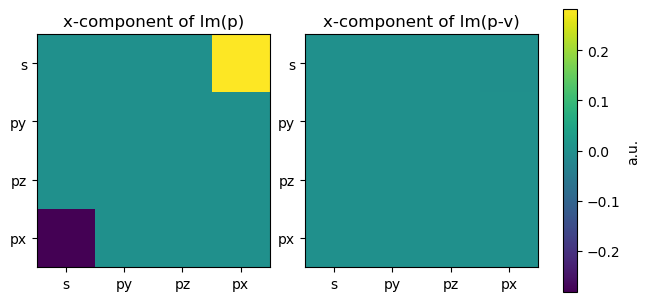

In [5]:

integrals = SlaterKosterIntegrator(atoms_unit_cell=atoms, skpath="skfiles_consistent/sk_unique", skpath_posop="skfiles_consistent/sk_posop_unique", maxl_dict=maxl, format="unique", path_p_onsite="skfiles_consistent/onsite_momentum")
integrals.check_p_v_onsite()

In [6]:
!cat onsite_p-v-consistency.txt

C: maximal abs deviation = 3.157227099870319e-05, maximal rel deviation = 0.00011204406145576508
 (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00-3.157227099868063769e-05j)
 (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)
 (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)
 (0.000000000000000000e+00+3.157227099870318909e-05j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+0.000000000000000000e+00j)

 (0.000000000000000000e+00+0.000000000

Result: Much smaller error. Wavefunction-consistent parameters seem to be an actual problem.
Now try also for offsite elements

(np.int64(0), np.int64(3), np.int64(5))


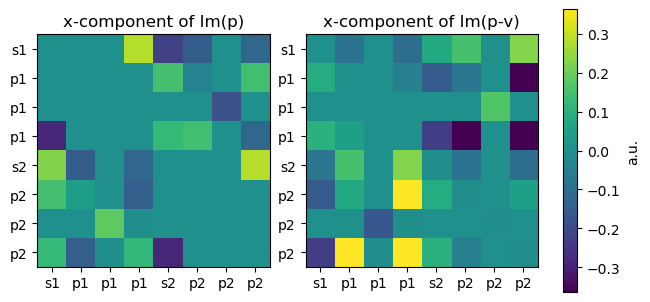

In [7]:
integrals.check_p_v_offsite()

In [8]:

!cat offsite_p-v-consistency.txt

onsite blocks: max|p - v| = 1.000e-01 a.u., relative to max|p|: 3.550e-01
offsite blocks: max|p - v| = 3.643e-01 a.u., relative to max|p|: 1.293e+00
entries with p = 0 but v != 0: 24

# component x: p - v
 (0.000000000000000000e+00+3.394598907524581932e-10j)  (0.000000000000000000e+00-8.651594146820132392e-02j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00-1.000391243774281791e-01j)  (0.000000000000000000e+00+7.871954156533617075e-02j)  (0.000000000000000000e+00+1.520719427576131821e-01j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00+2.304496548796142741e-01j)
 (0.000000000000000000e+00+8.651594105124214840e-02j)  (0.000000000000000000e+00+1.488824619144679673e-10j)  (0.000000000000000000e+00+0.000000000000000000e+00j)  (0.000000000000000000e+00-4.803128165155581830e-02j)  (0.000000000000000000e+00-1.520719428800941520e-01j)  (0.000000000000000000e+00-7.787245309414059236e-02j)  (0.000000000000000000e+00+0.0000000000

Problem: Wavefunction inconsistency does not resolve the error for offsite elements. Bug or basis set trunctation error?

How complete is the basis? SVD for onsite and offsite S

In [9]:
import numpy as np
S = integrals._calculate_lattice_dict(operator="S")[(0,0,0)]
print(S)
U, Sv, V_h = np.linalg.svd(a=S)
print(Sv)
print(np.sum(Sv))

[[ 1.          0.          0.          0.          0.30901794  0.18444623
   0.          0.31947024]
 [ 0.          1.          0.          0.         -0.18444623  0.04618857
   0.         -0.24664307]
 [ 0.          0.          1.          0.          0.          0.
   0.18858801  0.        ]
 [ 0.          0.          0.          1.         -0.31947024 -0.24664307
   0.         -0.23861032]
 [ 0.30901794 -0.18444623  0.         -0.31947024  1.          0.
   0.          0.        ]
 [ 0.18444623  0.04618857  0.         -0.24664307  0.          1.
   0.          0.        ]
 [ 0.          0.          0.18858801  0.          0.          0.
   1.          0.        ]
 [ 0.31947024 -0.24664307  0.         -0.23861032  0.          0.
   0.          1.        ]]
[1.71565836 1.18858801 1.18858801 1.02563067 0.97436933 0.81141199
 0.81141199 0.28434164]
8.0
